The idea behind this visualization is to be able to see how which token may or may not contain information about the sattelite. in most cases, it does not contain any information

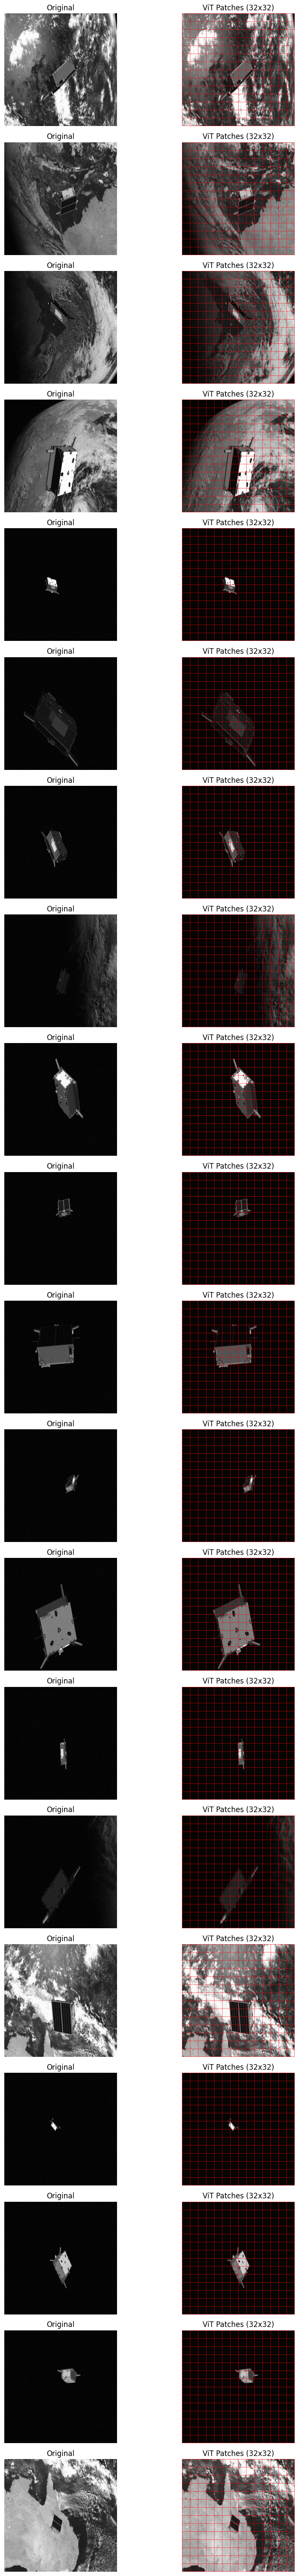

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from src.datasets import SPEEDDataset
from types import SimpleNamespace
import os
import cv2


def denormalize_image(tensor):
    """Denormalize image tensor to numpy array"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = tensor.numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img


def ensure_dir(directory):
    """Create directory if it doesn't exist"""
    if not os.path.exists(directory):
        os.makedirs(directory)


def draw_grid(image, patch_size=32):
    """Draw a grid on the image to show ViT patches"""
    img_with_grid = image.copy()
    height, width = image.shape[:2]

    # Draw vertical lines (including the right border)
    for x in range(0, width + patch_size, patch_size):
        x = min(x, width - 1)  # Ensure we don't go beyond the image width
        cv2.line(img_with_grid, (x, 0), (x, height - 1), (1, 0, 0), 1)

    # Draw horizontal lines (including the bottom border)
    for y in range(0, height + patch_size, patch_size):
        y = min(y, height - 1)  # Ensure we don't go beyond the image height
        cv2.line(img_with_grid, (0, y), (width - 1, y), (1, 0, 0), 1)

    # Explicitly draw the right and bottom borders
    cv2.line(img_with_grid, (width - 1, 0), (width - 1, height - 1), (1, 0, 0), 1)
    cv2.line(img_with_grid, (0, height - 1), (width - 1, height - 1), (1, 0, 0), 1)

    return img_with_grid


def visualize_vit_patches(dataset_path, num_samples=5):
    # Create output directories
    ensure_dir("new_images/original")
    ensure_dir("new_images/grid")

    # Args for original images (no augmentations)
    args_original = SimpleNamespace(
        no_pixel_augmentation=True,
        no_spatial_augmentation=True,
        no_translation_compensation=False,
        no_rotation_compensation=False,
    )

    # Create dataset
    dataset_original = SPEEDDataset(
        dataset_path, split="train", args=args_original, img_size=(448, 448)
    )

    # Create figure
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 3 * num_samples))

    for i in range(num_samples):
        # Get random image
        idx = np.random.randint(len(dataset_original))

        # Get original filename
        filename = dataset_original.data[idx]["filename"]
        basename = os.path.splitext(filename)[0]

        # Get original image
        img_orig, _, _, _ = dataset_original[idx]
        img_orig = denormalize_image(img_orig)

        # Create grid version
        img_grid = draw_grid(img_orig, patch_size=32)

        # Save images
        plt.imsave(f"new_images/original/{basename}.png", img_orig)
        plt.imsave(f"new_images/grid/{basename}.png", img_grid)

        # Plot images
        axes[i, 0].imshow(img_orig)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(img_grid)
        axes[i, 1].set_title("ViT Patches (32x32)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Might need to change the dataset path
    dataset_path = "../SPEED_FIXED"
    visualize_vit_patches(dataset_path, num_samples=20)